# Environment

In [2]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import r2_score

In [3]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data_ynsp.sqlite'

# Data

In [4]:
df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  's_13_28_5_9_16_80'
        )
gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["x"], df["y"]),
                crs="EPSG:3857"
                )

In [5]:
gdf

,unit_id,x,y,T,T_tot,T_tot_cat,ODR_1,ODR_2,ODR_3,ODR_4,Cont_T_N,C1,C2,tau,spill,Y_dep_var,Y_dep_var_ns,geometry
0,1000,0,0,0,0,control,0,0,0,0,0.0,1.493748,1.056517,0.0,0.0,1.427099,1.427099,POINT (0 0)
1,1001,0,100,0,0,control,0,0,0,0,0.0,0.532847,2.206003,0.0,0.0,1.895286,1.895286,POINT (0 100)
2,1002,0,200,0,0,control,0,0,0,0,0.0,-0.407365,0.879974,0.0,0.0,-0.181668,-0.181668,POINT (0 200)
3,1003,0,300,0,0,control,0,0,0,0,0.0,-0.371435,0.360218,0.0,0.0,-0.241598,-0.241598,POINT (0 300)
4,1004,0,400,0,0,control,0,0,0,0,0.0,-0.754499,-0.123365,0.0,0.0,0.490949,0.490949,POINT (0 400)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1795,3900,1500,0,0,control,0,0,0,0,0.0,0.813577,0.965252,0.0,0.0,1.710102,1.710102,POINT (3900 1500)
796,1796,3900,1600,0,0,control,0,0,0,0,0.0,1.287494,1.767809,0.0,0.0,0.983711,0.983711,POINT (3900 1600)
797,1797,3900,1700,0,0,control,0,0,0,0,0.0,1.215215,-2.129720,0.0,0.0,-0.178577,-0.178577,POINT (3900 1700)
798,1798,3900,1800,0,0,control,0,0,0,0,0.0,0.350681,-0.352717,0.0,0.0,-1.178801,-1.178801,POINT (3900 1800)


In [6]:
gdf_pre =gdf.copy()
gdf = gdf_pre.drop(columns = [c for c in gdf_pre.columns.tolist() if 'spatial_predictor' in c]).copy()
# df = import_non_spatial_data_frame(
#                 connection_link = connection_link_var,
#                 df_to_return_name =  'gdf_rho_0_75_sp_t_dr5'
#                                         )

df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
gdf2 = gdf.merge(df2, on = ['unit_id'])

# Modelling causal inference

## Single df

### Data preparation

In [7]:
X_ns = gdf2[["C1","C2",
         ]].values
X = gdf2[["C1","C2",
    #      'spatial_predictor_100_1',
    # 'spatial_predictor_100_3',
    # 'spatial_predictor_100_4',
    # 'spatial_predictor_100_2',
    # 'spatial_predictor_100_6',
    # 'spatial_predictor_100_5',
    # 'spatial_predictor_100_9',
    # 'spatial_predictor_500_9',
    # 'spatial_predictor_100_10'
         ]].values
y = gdf2["Y_dep_var"].values.reshape(-1,1)
T = gdf2["T"].values


T_tot = gdf2["T_tot"].values
Xdf = gdf2[['T','ODR_1','ODR_2','ODR_3',
            #'odr_4', 
            "C1","C2",
    #      'spatial_predictor_100_1',
    # 'spatial_predictor_100_3',
    # 'spatial_predictor_100_4',
    # 'spatial_predictor_100_2',
    # 'spatial_predictor_100_6',
    # 'spatial_predictor_100_5',
    # 'spatial_predictor_100_9',
    # 'spatial_predictor_500_9',
    # 'spatial_predictor_100_10'
         ]]
Xdf2 = gdf2[['T','ODR_1','ODR_2','ODR_3',
            #'odr_4', 
            "C1","C2",
         #"C3","Cs"
         ]]


Xdf3 = gdf2[['T',
            #'odr_4', 
            "C1","C2",
    #      'spatial_predictor_100_1',
    # 'spatial_predictor_100_3',
    # 'spatial_predictor_100_4',
    # 'spatial_predictor_100_2',
    # 'spatial_predictor_100_6',
    # 'spatial_predictor_100_5',
    # 'spatial_predictor_100_9',
    # 'spatial_predictor_500_9',
    # 'spatial_predictor_100_10'
         ]]

Xdf4 = gdf2[['T',
            #'odr_4', 
            "C1","C2",
         ]]

X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
X_l3 = sm.add_constant(Xdf3)
X_l4 = sm.add_constant(Xdf4)
y_l = gdf2["Y_dep_var"]
Y = gdf2['Y_dep_var'].values

gdf3 = gdf2.copy()

gdf3["t_catS"] = gdf3['T']
gdf3["t_catS"] = gdf3["t_catS"].replace({
    0: "control",
    1: "inner_ring"
})

T_S= gdf3['t_catS'].values

gdf3['t_tot_cat3'] = gdf3['T_tot_cat']
gdf3.loc[gdf3['T_tot_cat']=='treated_outer_ring4', 't_tot_cat3'] = 'control'

T_M= gdf3['t_tot_cat3'].values
T_M= T_M.astype(str)

gdf4 = gdf2.copy()[['unit_id',
            'T',
            #'propensity',
            'T_tot', 'T_tot_cat']]
gdf4.loc[(gdf4['T_tot'] == 1)&(gdf4['T'] != 1), 't_double']= 1
gdf4['t_double_cat'] = gdf4['T_tot_cat'].replace({ 
    'treated_outer_ring4':'control',
     'treated_outer_ring3':'treated_outer_ring',                                             
      'treated_outer_ring2':'treated_outer_ring',
      'treated_outer_ring1':'treated_outer_ring',                                            
                                                  })
gdf4 = gdf4.fillna(0)



T_Dbl= gdf4['t_double_cat'].values
T_Dbl= T_Dbl.astype(str)

gdf3 = gdf3.rename(columns = {'T': 'treated_inner_ring',
                              'ODR_1':'treated_outer_ring1', 
                              'ODR_2':'treated_outer_ring2', 
                              'ODR_3':'treated_outer_ring3', 
                              'ODR_4':'treated_outer_ring4'
                              })
T_mult = gdf3[[ 
         'treated_inner_ring', 'treated_outer_ring1','treated_outer_ring2','treated_outer_ring3',
         #'treated_outer_ring4'
         ]].to_numpy()

gdf5 = gdf4.copy()


gdf5 = gdf5.rename(columns = {'T': 'treated_inner_ring',
                              't_double':'treated_outer_rings', 
                              })

T_DT = gdf5[[ 
         'treated_inner_ring', 'treated_outer_rings'
         ]].to_numpy()



T_DT_id = gdf2[[ 
         'T', 'Cont_T_N'
         ]].to_numpy()

gdf2_22 = gdf.copy()
gdf2_22["x"] = gdf2_22.geometry.x.astype(int)
gdf2_22["y"] = gdf2_22.geometry.y.astype(int)

n = len(gdf2_22)

coords = np.array(
        list(zip(gdf2_22["x"], gdf2_22["y"]))
    )


W_mat = DistanceBand(
        coords,
        threshold=100 + 1,
        binary=True,
        silence_warnings=True
    ) 

In [8]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                            #4:'treated_outer_ring4'
                                             }

replacing_dict_odr_ring = {'T':'treated_inner_ring', 
                                                                        'ODR_1':'treated_outer_ring1', 
                                                                        'ODR_2':'treated_outer_ring2',
                                                                        'ODR_3':'treated_outer_ring3',
                                                                          #'odr_4':'treated_outer_ring4'
                                                                          }

### Multi treatment

#### With spatial regressors

##### S learner

In [9]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT, lb_slearn_multT, ub_slearn_multT = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite_slearn_multT = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df_slearn_multT = pd.DataFrame(ite_slearn_multT).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_multT['treated'] = T_M
ITE_df_slearn_multT['ITE_real'] = gdf2['tau']
ITE_df_slearn_multT['Y'] = Y
ITE_df_slearn_multT

,treated_inner_ring,treated_outer_ring1,treated_outer_ring2,treated_outer_ring3,treated,ITE_real,Y
0,2.410300,0.727058,0.733329,0.068736,control,0.0,1.427099
1,3.213675,0.248320,0.693721,0.026508,control,0.0,1.895286
2,2.162670,0.926145,0.724797,-0.110134,control,0.0,-0.181668
3,1.419004,0.793362,0.168833,-0.077905,control,0.0,-0.241598
4,0.987292,0.232061,0.056082,-0.000331,control,0.0,0.490949
...,...,...,...,...,...,...,...
795,1.565387,0.437241,0.715578,0.015145,control,0.0,1.710102
796,3.260157,0.607737,1.302167,0.038773,control,0.0,0.983711
797,0.814635,0.998273,0.013222,0.007259,control,0.0,-0.178577
798,2.784148,1.149649,0.752283,0.206297,control,0.0,-1.178801


In [10]:
df_effectbase = pd.DataFrame({
                'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2','treated_outer_ring3',
                        #'treated_outer_ring4'
                        ],
              'true_effect':[gdf2[gdf2['T'] == 1]['tau'].mean(), gdf2[gdf2['ODR_1'] == 1]['tau'].mean(), 
                             gdf2[gdf2['ODR_2'] == 1]['tau'].mean(), gdf2[gdf2['ODR_3'] == 1]['tau'].mean(), 
                               #gdf2[gdf2['odr_4'] == 1]['tau'].mean()
                               ],
              })
df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_slearn_multT,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_sp', treated_col='treated')
df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')
df_multi_effect_pre1

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp
0,treated_inner_ring,1.500000,1.670705,0.087813
1,treated_outer_ring1,0.888615,0.975702,0.080879
2,treated_outer_ring2,0.535973,0.356422,0.060130
3,treated_outer_ring3,0.111990,0.088714,0.037156


##### Causal forest

In [11]:
est2 = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

te_pred2 = est2.const_marginal_effect(X)
ITE_CF=pd.DataFrame(te_pred2).rename(columns = replacing_dict_0_ring)
ITE_CF['treated'] = T_M
df_multi_treatment_effects_CF = make_treatment_effects_df(ITE_CF,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_sp', treated_col='treated')
df_multi_effect_pre3 = df_multi_effect_pre1.merge(df_multi_treatment_effects_CF, on = 'ring', how= 'left')
df_multi_effect_pre3 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mCF_sp,se_mCF_sp
0,treated_inner_ring,1.500000,1.670705,0.087813,1.624326,0.044809
1,treated_outer_ring1,0.888615,0.975702,0.080879,1.148102,0.050619
2,treated_outer_ring2,0.535973,0.356422,0.060130,0.551372,0.056233
3,treated_outer_ring3,0.111990,0.088714,0.037156,0.211690,0.035081


##### Cross sectional DiD with spatial predictors

In [12]:
model_cs_did_sp_pred = sm.OLS(y_l, X_l)
results_cs_did_sp_pred = model_cs_did_sp_pred.fit()

coef_df_cs_did_sp_pred = pd.DataFrame({
    "ring": results_cs_did_sp_pred.params.index,
    "att_mDiD_sp_pred": results_cs_did_sp_pred.params.values,
    "se_mDiD_sp_pred": results_cs_did_sp_pred.bse.values
})
coef_df_cs_did_sp_pred = coef_df_cs_did_sp_pred[coef_df_cs_did_sp_pred['ring'].isin(['T', 
                                                            'ODR_1', 'ODR_2',
                                                            'ODR_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did_sp_pred['ring'] = coef_df_cs_did_sp_pred['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_pre4 = df_multi_effect_pre3.merge(coef_df_cs_did_sp_pred, on = 'ring', how= 'left')
df_multi_effect_pre4

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred
0,treated_inner_ring,1.500000,1.670705,0.087813,1.624326,0.044809,1.642229,0.106301
1,treated_outer_ring1,0.888615,0.975702,0.080879,1.148102,0.050619,1.130438,0.142436
2,treated_outer_ring2,0.535973,0.356422,0.060130,0.551372,0.056233,0.643824,0.136567
3,treated_outer_ring3,0.111990,0.088714,0.037156,0.211690,0.035081,0.180350,0.126909


##### SDM DiD

In [13]:
did_sdm_ysp = ML_Lag(
    y,
    X_l2,
    w=W_mat,              
    slx_lags=0,       
    name_y="y",
    # name_x=['t','odr_1','odr_2','odr_3','odr_4', "c1","c2"
    #         ]
)

did_sdm_ysp_coefs = did_sdm_ysp.betas.flatten()
did_sdm_ysp_ses = np.sqrt(np.diag(did_sdm_ysp.vm))
did_sdm_ysp_variables = did_sdm_ysp.name_x.copy()

coef_did_sdm_ysp = pd.DataFrame({
    "ring": did_sdm_ysp_variables,
    "att_sdm": did_sdm_ysp_coefs,
    "att_sdm_se": did_sdm_ysp_ses 
})
coef_did_sdm_ysp = coef_did_sdm_ysp[coef_did_sdm_ysp['ring'].isin(['T', 
                                                            'ODR_1', 'ODR_2',
                                                            'ODR_3',])]
coef_did_sdm_ysp['ring'] = coef_did_sdm_ysp['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_sp_regr = df_multi_effect_pre4.merge(coef_did_sdm_ysp, on = 'ring', how= 'left')
df_multi_effect_sp_regr

ML_Lag


,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se
0,treated_inner_ring,1.500000,1.670705,0.087813,1.624326,0.044809,1.642229,0.106301,1.559854,0.122206
1,treated_outer_ring1,0.888615,0.975702,0.080879,1.148102,0.050619,1.130438,0.142436,1.072221,0.148202
2,treated_outer_ring2,0.535973,0.356422,0.060130,0.551372,0.056233,0.643824,0.136567,0.619799,0.137149
3,treated_outer_ring3,0.111990,0.088714,0.037156,0.211690,0.035081,0.180350,0.126909,0.174244,0.126354


##### Results visualization

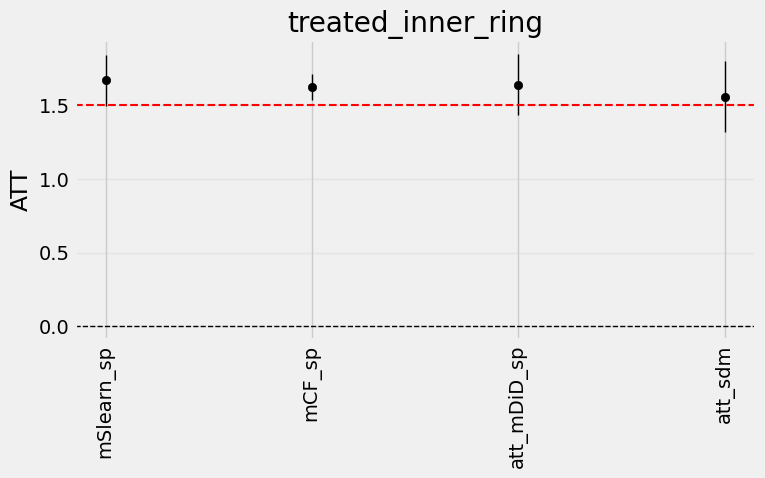

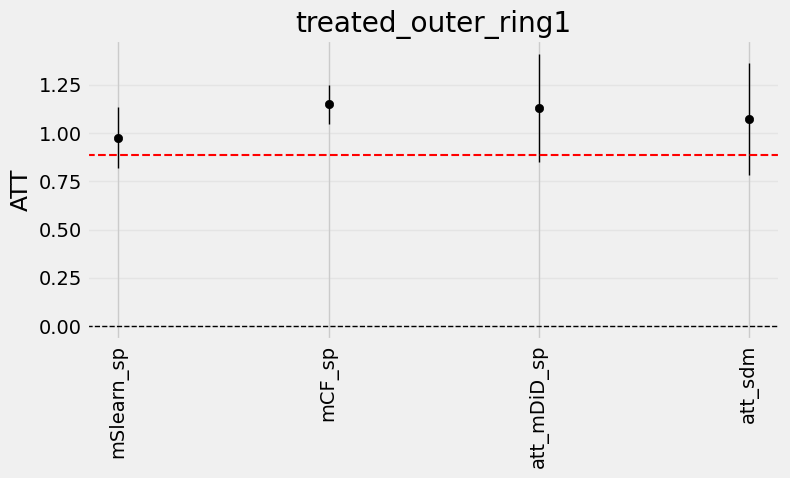

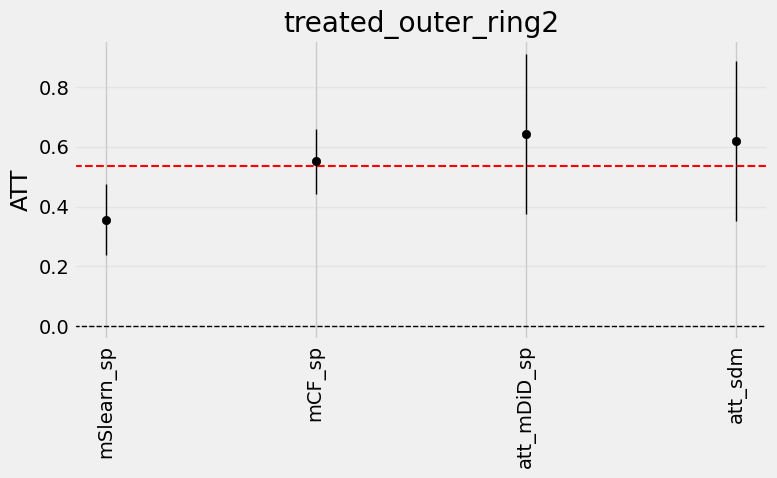

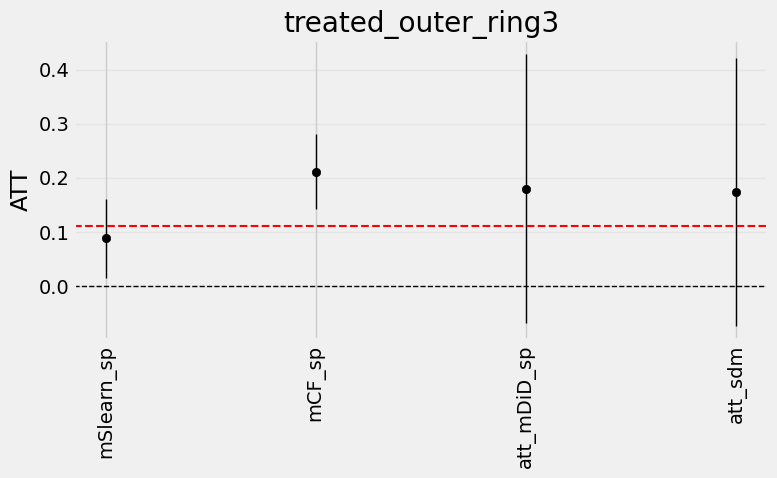

In [14]:
att_models_sp = {
    "mSlearn_sp": ("att_mSlearn_sp", "se_mSlearn_sp"),
    "mCF_sp": ("att_mCF_sp", "se_mCF_sp"),
    "att_mDiD_sp": ("att_mDiD_sp_pred", "se_mDiD_sp_pred"),
    "att_sdm": ("att_sdm", "att_sdm_se"),

}
for ring in df_multi_effect_sp_regr['ring'].unique().tolist():
    plot_att_row(
        df=df_multi_effect_sp_regr,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_sp
    )

### Single treatment

#### With spatial regressors

##### S learner

In [15]:
RF_s_learnerS = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_Sngl, lb_slearn_Sngl, ub_slearn_Sngl = RF_s_learnerS.estimate_ate(X, T_S, Y, return_ci = True)
ite_slearn_Sngl = RF_s_learnerS.fit_predict(X, T_S, Y)
ITE_df_slearn_Sngl = pd.DataFrame(ite_slearn_Sngl).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_Sngl['treated'] = T_M
ITE_df_slearn_Sngl['ITE_real'] = gdf2['tau']
ITE_df_slearn_Sngl['Y'] = Y
ITE_df_slearn_Sngl

,treated_inner_ring,treated,ITE_real,Y
0,2.526113,control,0.0,1.427099
1,3.269468,control,0.0,1.895286
2,2.071430,control,0.0,-0.181668
3,1.225543,control,0.0,-0.241598
4,1.026080,control,0.0,0.490949
...,...,...,...,...
795,1.672366,control,0.0,1.710102
796,2.997067,control,0.0,0.983711
797,0.761920,control,0.0,-0.178577
798,2.494266,control,0.0,-1.178801


In [16]:
df_single_treatment_effects_SlearnS = make_treatment_effects_df(ITE_df_slearn_Sngl,  [ 'treated_inner_ring',
             ],'sSlearn_sp', treated_col='treated')
df_single_effect_pre1 = df_effectbase[df_effectbase['ring'] == 'treated_inner_ring'].merge(df_single_treatment_effects_SlearnS, on = 'ring', how= 'left')
df_single_effect_pre1

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp
0,treated_inner_ring,1.5,1.481917,0.089246


In [17]:
ITE_df_slearn_Sngl['treated'].unique()

array(['control', 'treated_outer_ring3', 'treated_outer_ring2',
       'treated_outer_ring1', 'treated_inner_ring'], dtype=object)

In [18]:
ITE_df_slearn_Sngl[ITE_df_slearn_Sngl['treated'] == 'treated_outer_ring1']

,treated_inner_ring,treated,ITE_real,Y
245,0.651002,treated_outer_ring1,0.856176,1.969883
246,1.365793,treated_outer_ring1,0.428965,-2.099782
247,0.845217,treated_outer_ring1,1.081503,3.165640
248,0.539448,treated_outer_ring1,1.001572,1.504842
249,1.858721,treated_outer_ring1,1.103466,1.342934
264,1.267662,treated_outer_ring1,0.562009,-0.217025
270,1.512904,treated_outer_ring1,0.361779,0.883197
284,2.046177,treated_outer_ring1,1.223421,0.707125
290,0.538001,treated_outer_ring1,0.478149,0.191412
304,1.845520,treated_outer_ring1,1.193132,2.355403


##### Causal forest

In [19]:
est2S = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2S.tune(Y, T, X=X, 
          #W=W
          )
est2S.fit(Y, T, X=X, 
         #W=W
         )

te_pred2S = est2S.const_marginal_effect(X)
ITE_CFS=pd.DataFrame(te_pred2S).rename(columns = replacing_dict_0_ring)
ITE_CFS['treated'] = T_M
df_single_treatment_effects_CF = make_treatment_effects_df(ITE_CFS,  ['treated_inner_ring',
            # 'treated_outer_ring1',
            #  'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'sCF_sp', treated_col='treated')
df_single_effect_pre2 = df_single_effect_pre1.merge(df_single_treatment_effects_CF, on = 'ring', how= 'left')
df_single_effect_pre2

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp,att_sCF_sp,se_sCF_sp
0,treated_inner_ring,1.5,1.481917,0.089246,1.489346,0.04247


In [20]:
y_base = est2S.models_y[0][0].predict(X)
tau_hat = est2S.effect(X)

# final prediction
y_hat = y_base + tau_hat * T

# R²
r2 = r2_score(Y, y_hat)
r2

0.5587799390699554

##### DiD

In [21]:
model_cs_did_sp_pred_single = sm.OLS(y_l, X_l3)
results_cs_did_sp_pred_single = model_cs_did_sp_pred_single.fit()

coef_df_cs_did_sp_pred_single = pd.DataFrame({
    "ring": results_cs_did_sp_pred_single.params.index,
    "att_sDiD_sp_pred": results_cs_did_sp_pred_single.params.values,
    "se_sDiD_sp_pred": results_cs_did_sp_pred_single.bse.values
})
coef_df_cs_did_sp_pred_single = coef_df_cs_did_sp_pred_single[coef_df_cs_did_sp_pred_single['ring'].isin(['T'
                                                            ])].copy()

coef_df_cs_did_sp_pred_single['ring'] = coef_df_cs_did_sp_pred_single['ring'].replace(replacing_dict_odr_ring)
df_single_effect_final = df_single_effect_pre2.merge(coef_df_cs_did_sp_pred_single, on = 'ring', how= 'left')
df_single_effect_final

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp,att_sCF_sp,se_sCF_sp,att_sDiD_sp_pred,se_sDiD_sp_pred
0,treated_inner_ring,1.5,1.481917,0.089246,1.489346,0.04247,1.520831,0.109997


##### Resuts visualization

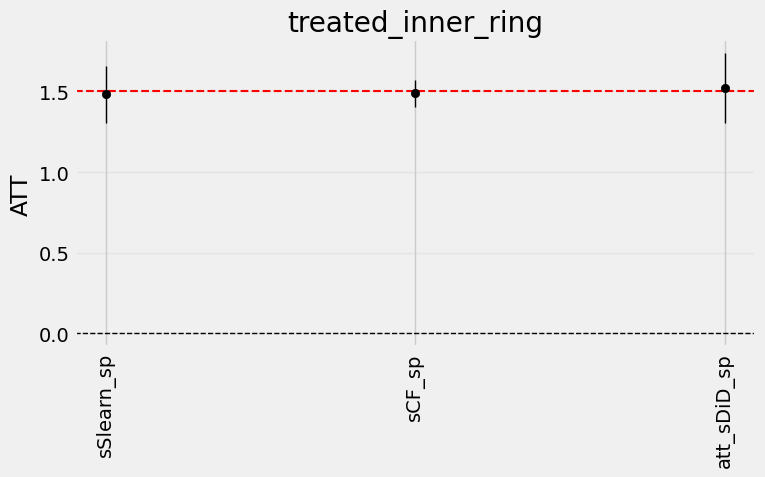

In [22]:
att_models_sp_single = {
    "sSlearn_sp": ("att_sSlearn_sp", "se_sSlearn_sp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "sCF_sp": ("att_sCF_sp", "se_sCF_sp"),
    "att_sDiD_sp": ("att_sDiD_sp_pred", "se_sDiD_sp_pred"),

}

plot_att_row(
        df=df_single_effect_final,
        ring_name='treated_inner_ring',
        true_effect_col="true_effect",
        att_dict=att_models_sp_single
    )

### Double treatment

#### S learner

In [23]:
RF_s_learner_nsp_DT = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT_nsp_DT, lb_slearn_multT_nsp_DT, ub_slearn_multT_nsp_DT = RF_s_learner_nsp_DT.estimate_ate(
    X_ns, T_Dbl, Y, return_ci = True)
ite_slearn_multT_nsp_DT = RF_s_learner_nsp_DT.fit_predict(X_ns, T_Dbl, Y)
ITE_df_slearn_multT_nsp_DT = pd.DataFrame(ite_slearn_multT_nsp_DT).rename(columns = {
                                            0:'treated_inner_ring', 1:'treated_outer_rings', 
                                             })
ITE_df_slearn_multT_nsp_DT['treated'] = T_M
df_dbl_treatment_effects_Slearn_nsp  = make_att_table(
    df=ITE_df_slearn_multT_nsp_DT,
    inner_ring='treated_inner_ring',
    outer_rings=[
        'treated_outer_ring1',
        'treated_outer_ring2',
        'treated_outer_ring3'
    ],
    treated_col='treated',
    suffix='Slearn_dblT'
)
df_double_vt_pre1 = df_effectbase.merge(df_dbl_treatment_effects_Slearn_nsp, on = 'ring', how= 'left')
df_double_vt_pre1

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT
0,treated_inner_ring,1.500000,1.670705,0.087813
1,treated_outer_ring1,0.888615,0.656554,0.066057
2,treated_outer_ring2,0.535973,0.425451,0.061151
3,treated_outer_ring3,0.111990,0.310629,0.060211


#### Causal forest

In [24]:
est2_cf_nsp_dt = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp_dt.tune(Y, T_DT, X=X_ns, 
          #W=W
          )
est2_cf_nsp_dt.fit(Y, T_DT, X=X_ns, 
         #W=W
         )

te_pred2_nsp_dt = est2_cf_nsp_dt.const_marginal_effect(X_ns)
ITE_CF_nsp_DT=pd.DataFrame(te_pred2_nsp_dt ).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                             })
ITE_CF_nsp_DT['treated'] = T_M


df_dbl_treatment_effects_CF  = make_att_table(
    df=ITE_CF_nsp_DT,
    inner_ring='treated_inner_ring',
    outer_rings=[
        'treated_outer_ring1',
        'treated_outer_ring2',
        'treated_outer_ring3'
    ],
    treated_col='treated',
    suffix='CF_dblT'
)
df_double_vt_pre2 = df_double_vt_pre1.merge(df_dbl_treatment_effects_CF, on = 'ring', how= 'left')
df_double_vt_pre2

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT,att_CF_dblT,se_att_CF_dblT
0,treated_inner_ring,1.500000,1.670705,0.087813,1.592150,0.043539
1,treated_outer_ring1,0.888615,0.656554,0.066057,0.381809,0.014215
2,treated_outer_ring2,0.535973,0.425451,0.061151,0.356670,0.015225
3,treated_outer_ring3,0.111990,0.310629,0.060211,0.354031,0.013666


#### Causal forest inverse distance

In [25]:
est2_cf_nsp_dt_id = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp_dt_id.tune(Y, T_DT_id, X=X_ns, 
          #W=W
          )
est2_cf_nsp_dt_id.fit(Y, T_DT_id, X=X_ns, 
         #W=W
         )

te_pred2_nsp_dt_id = est2_cf_nsp_dt_id.const_marginal_effect(X_ns)
ITE_CF_nsp_DT_id=pd.DataFrame(te_pred2_nsp_dt_id ).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                             })
ITE_CF_nsp_DT_id['treated'] = T_M

ITE_CF_nsp_DT_id['treated_outer_ring1'] = ITE_CF_nsp_DT_id['treated_outer_rings']
ITE_CF_nsp_DT_id['treated_outer_ring2'] = ITE_CF_nsp_DT_id['treated_outer_rings']/2
ITE_CF_nsp_DT_id['treated_outer_ring3'] = ITE_CF_nsp_DT_id['treated_outer_rings']/3


df_dbl_treatment_effects_CF_id = make_treatment_effects_df(ITE_CF_nsp_DT_id,  ['treated_inner_ring',
            'treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'CF_id', treated_col='treated')

# df_dbl_treatment_effects_CF_id  = make_att_table(
#     df=ITE_CF_nsp_DT_id,
#     inner_ring='treated_inner_ring',
#     outer_rings=[
#         'treated_outer_ring1',
#         'treated_outer_ring2',
#         'treated_outer_ring3'
#     ],
#     treated_col='treated',
#     suffix='CF_dblT_id'
# )
df_double_vt_final = df_double_vt_pre2.merge(df_dbl_treatment_effects_CF_id, on = 'ring', how= 'left')
df_double_vt_final

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT,att_CF_dblT,se_att_CF_dblT,att_CF_id,se_CF_id
0,treated_inner_ring,1.500000,1.670705,0.087813,1.592150,0.043539,1.605481,0.044181
1,treated_outer_ring1,0.888615,0.656554,0.066057,0.381809,0.014215,1.139693,0.038437
2,treated_outer_ring2,0.535973,0.425451,0.061151,0.356670,0.015225,0.560124,0.015836
3,treated_outer_ring3,0.111990,0.310629,0.060211,0.354031,0.013666,0.386988,0.013336


#### Results visualization

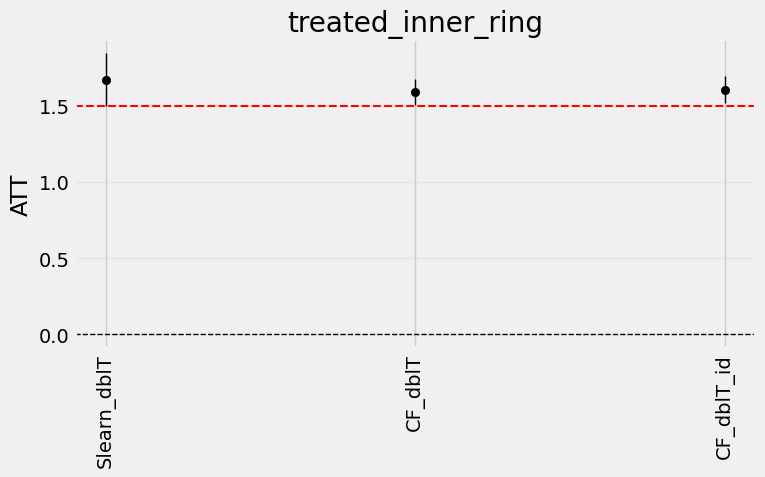

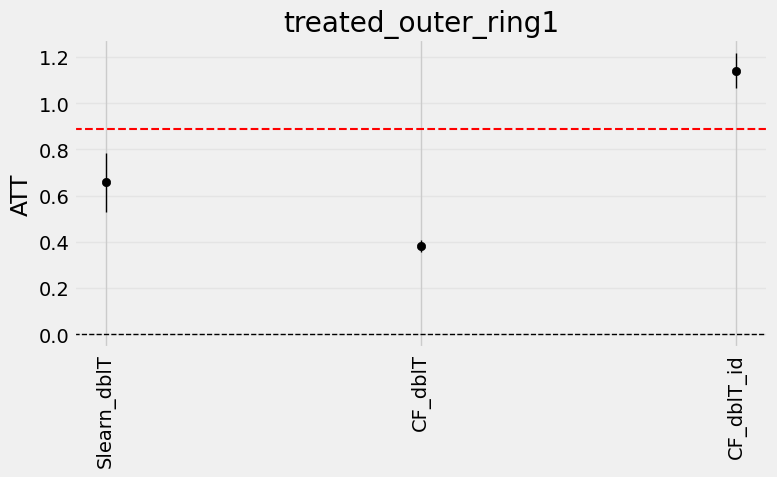

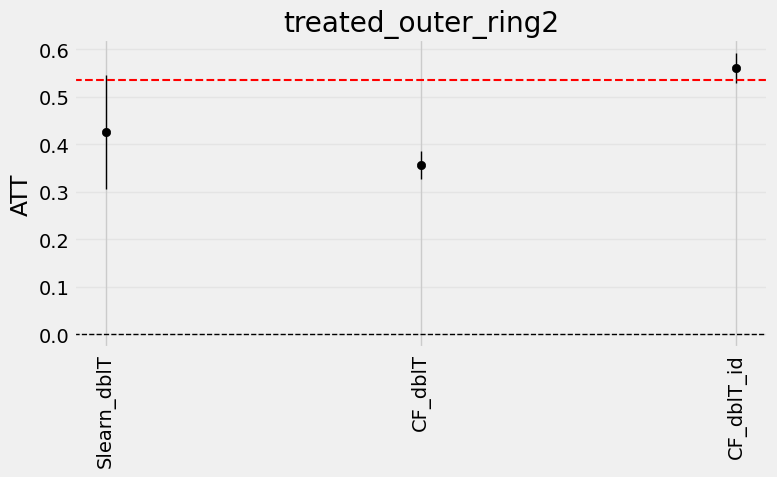

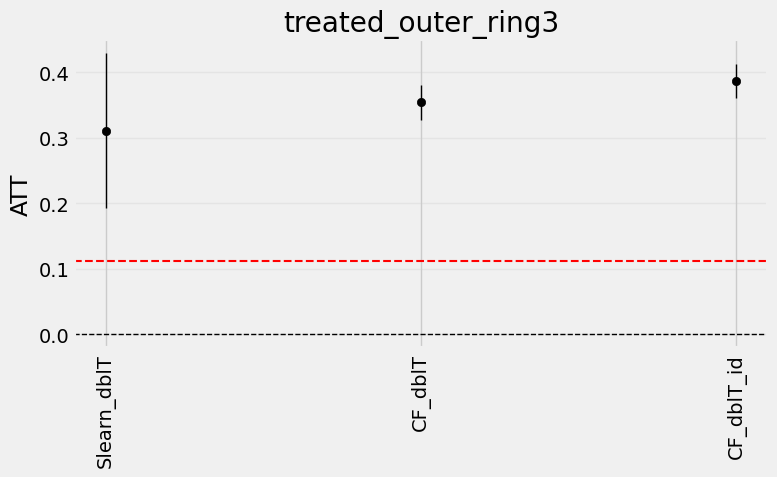

In [26]:
att_models_nspreg_id = {
    "Slearn_dblT": ("att_Slearn_dblT", "se_att_Slearn_dblT"),
    "CF_dblT": ("att_CF_dblT", "se_att_CF_dblT"),
    "CF_dblT_id": ("att_CF_id", "se_CF_id")
}
for ring in df_double_vt_final['ring'].unique().tolist():
    plot_att_row(
        df=df_double_vt_final,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_nspreg_id
    )